In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd

from archifer.model import BuildingSector

df = pd.read_excel("../data/archetypes_v1.xlsx", index_col=0)

bs = BuildingSector(df)
bs.ids[:5]

['EFH I_Bis 1919_biogene',
 'EFH I_Bis 1919_dh',
 'EFH I_Bis 1919_fossil',
 'EFH I_Bis 1919_hp',
 'EFH I_Bis 1919_reno_biogene']

In [2]:

from archifer.parser import *
constraints = parse_yaml_config("../data/test_constraints.yaml")
constraints
for name, props in constraints.items():
    print(name, props)

Af_total {'type': 'equals', 'column': 'Af_m2', 'target': 878085}
Statcube_residential {'type': 'equals', 'column': 'Af_m2', 'filter': "residential=='yes'", 'target': 541379}
Statcube_residential2 {'type': 'greater than target', 'column': 'Af_m2', 'filter': ["residential=='yes'", "building_period=='bis 1919'"], 'target': 73302}


In [3]:
for name, props in constraints.items():
    bs.add_yaml_constraint(name, props)

In [4]:
n = bs.solve()
n


Status: Optimal


EFH I_Bis 1919_biogene         0.0
EFH I_Bis 1919_dh              0.0
EFH I_Bis 1919_fossil          0.0
EFH I_Bis 1919_hp              0.0
EFH I_Bis 1919_reno_biogene    0.0
                              ... 
RH VII_2000-20_hp              0.0
RH VIII_>2020_biogene          0.0
RH VIII_>2020_dh               0.0
RH VIII_>2020_fossil           0.0
RH VIII_>2020_hp               0.0
Length: 228, dtype: float64

In [5]:
bs.model.constraints

{'Af_total': 210.08000000000004*n_EFH_III_1945_59_biogene + 210.08000000000004*n_EFH_III_1945_59_dh + 210.08000000000004*n_EFH_III_1945_59_fossil + 210.08000000000004*n_EFH_III_1945_59_hp + 210.08000000000004*n_EFH_III_1945_59_reno_biogene + 210.08000000000004*n_EFH_III_1945_59_reno_dh + 210.08000000000004*n_EFH_III_1945_59_reno_fossil + 210.08000000000004*n_EFH_III_1945_59_reno_hp + 210.08000000000004*n_EFH_II_1920_44_biogene + 210.08000000000004*n_EFH_II_1920_44_dh + 210.08000000000004*n_EFH_II_1920_44_fossil + 210.08000000000004*n_EFH_II_1920_44_hp + 210.08000000000004*n_EFH_II_1920_44_reno_biogene + 210.08000000000004*n_EFH_II_1920_44_reno_dh + 210.08000000000004*n_EFH_II_1920_44_reno_fossil + 210.08000000000004*n_EFH_II_1920_44_reno_hp + 210.08000000000004*n_EFH_IV_1960_79_biogene + 210.08000000000004*n_EFH_IV_1960_79_dh + 210.08000000000004*n_EFH_IV_1960_79_fossil + 210.08000000000004*n_EFH_IV_1960_79_hp + 210.08000000000004*n_EFH_IV_1960_79_reno_biogene + 210.08000000000004*n_EF

In [6]:
n_nonempty = n[n != 0]

<Axes: >

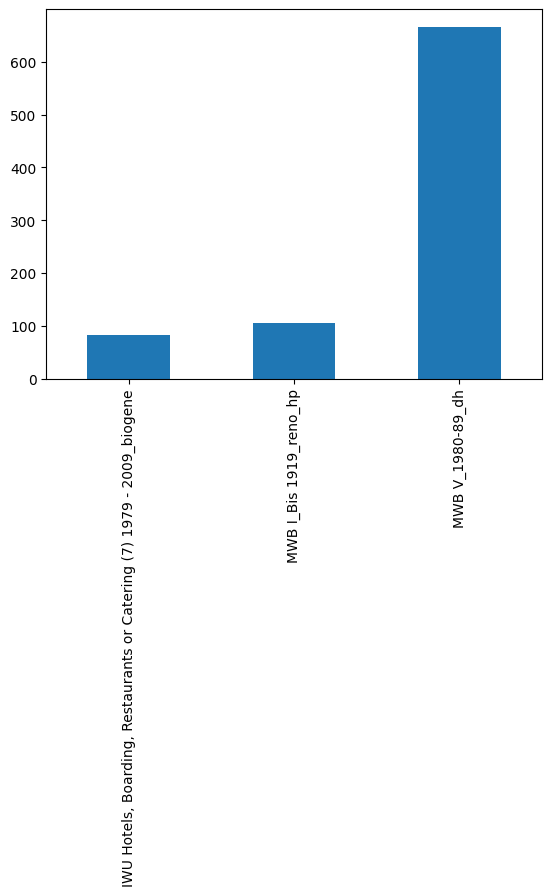

In [7]:
n_nonempty.plot(kind="bar")

In [8]:
statdf = pd.read_excel("../data/statcube_test.xlsx", sheet_name="clean")
statdf.head()


,Nutzung,usage,Bauperiode,count,NGF
0,Wohngebäude mit einer Wohnung,res_single_u,Vor 1919,172873,23473512
1,Wohngebäude mit einer Wohnung,res_single_u,1919 bis 1944,102392,11723038
2,Wohngebäude mit einer Wohnung,res_single_u,1945 bis 1960,147644,18161803
3,Wohngebäude mit einer Wohnung,res_single_u,1961 bis 1970,165174,21762413
4,Wohngebäude mit einer Wohnung,res_single_u,1971 bis 1980,202226,28584060


In [9]:

constraints = parse_yaml_config("../data/statcube_mappings.yaml")
mappings = constraints["mappings"]
mappings

{'usage': {'field': 'usage',
  'allowed_mappings': {'res_single_u': ['sfh', 'rh'],
   'res_double_u': ['sfh', 'rh'],
   'res_multi_u': ['rh', 'mfh'],
   'hostel': ['hotel'],
   'hotel': ['hotel'],
   'office': ['office'],
   'retail': ['trade'],
   'communication': [],
   'industry': ['industry'],
   'leasure': ['leasure']}}}

In [10]:

mapping_vars = {}

for data_slice, archetyp_slice in mappings["usage"]["allowed_mappings"].items():
    print(data_slice, archetyp_slice)
    possible_ids = []    
    for slice in archetyp_slice:
        possible_ids.extend(bs._filter_indices(f"usage=='{slice}'").tolist())
    ids = [f"statcube_{data_slice}_{id}" for id in possible_ids]

    # add variables
    mapping_vars[data_slice] = pl.LpVariable.dicts("n", ids, lowBound=0, cat="Integer")
    # add constraints



res_single_u ['sfh', 'rh']
res_double_u ['sfh', 'rh']
res_multi_u ['rh', 'mfh']
hostel ['hotel']
hotel ['hotel']
office ['office']
retail ['trade']
communication []
industry ['industry']
leasure ['leasure']


In [11]:
mapping_vars

{'res_single_u': {'statcube_res_single_u_EFH I_Bis 1919_biogene': n_statcube_res_single_u_EFH_I_Bis_1919_biogene,
  'statcube_res_single_u_EFH I_Bis 1919_dh': n_statcube_res_single_u_EFH_I_Bis_1919_dh,
  'statcube_res_single_u_EFH I_Bis 1919_fossil': n_statcube_res_single_u_EFH_I_Bis_1919_fossil,
  'statcube_res_single_u_EFH I_Bis 1919_hp': n_statcube_res_single_u_EFH_I_Bis_1919_hp,
  'statcube_res_single_u_EFH I_Bis 1919_reno_biogene': n_statcube_res_single_u_EFH_I_Bis_1919_reno_biogene,
  'statcube_res_single_u_EFH I_Bis 1919_reno_dh': n_statcube_res_single_u_EFH_I_Bis_1919_reno_dh,
  'statcube_res_single_u_EFH I_Bis 1919_reno_fossil': n_statcube_res_single_u_EFH_I_Bis_1919_reno_fossil,
  'statcube_res_single_u_EFH I_Bis 1919_reno_hp': n_statcube_res_single_u_EFH_I_Bis_1919_reno_hp,
  'statcube_res_single_u_EFH II_1920-44_biogene': n_statcube_res_single_u_EFH_II_1920_44_biogene,
  'statcube_res_single_u_EFH II_1920-44_dh': n_statcube_res_single_u_EFH_II_1920_44_dh,
  'statcube_res_si